In [1]:
import sys
sys.executable


'd:\\Projects\\state of georgia\\.venv\\Scripts\\python.exe'

In [2]:
import pandas as pd 
raw_df = pd.read_csv('ACSDP1Y2024.DP05-2026-01-25T142937.csv')

In [3]:
raw_df.head()

,Label (Grouping),United States!!Estimate,United States!!Margin of Error,United States!!Percent,United States!!Percent Margin of Error,Georgia!!Estimate,Georgia!!Margin of Error,Georgia!!Percent,Georgia!!Percent Margin of Error,"Barrow County, Georgia!!Estimate",...,"Walker County, Georgia!!Percent","Walker County, Georgia!!Percent Margin of Error","Walton County, Georgia!!Estimate","Walton County, Georgia!!Margin of Error","Walton County, Georgia!!Percent","Walton County, Georgia!!Percent Margin of Error","Whitfield County, Georgia!!Estimate","Whitfield County, Georgia!!Margin of Error","Whitfield County, Georgia!!Percent","Whitfield County, Georgia!!Percent Margin of Error"
0,SEX AND AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total population,"340,110,990",*****,"340,110,990",(X),"11,180,878",*****,"11,180,878",(X),"96,294",...,"69,340",(X),"109,792",*****,"109,792",(X),"105,070",*****,"105,070",(X)
2,Male,"168,294,343","±32,107",49.5%,±0.1,"5,441,586","±9,788",48.7%,±0.1,"47,186",...,48.2%,±1.0,"53,801","±1,267",49.0%,±1.2,"53,844",±680,51.2%,±0.6
3,Female,"171,816,647","±32,107",50.5%,±0.1,"5,739,292","±9,788",51.3%,±0.1,"49,108",...,51.8%,±1.0,"55,991","±1,267",51.0%,±1.2,"51,226",±680,48.8%,±0.6
4,Sex ratio (males per 100 females),97.9,±0.1,(X),(X),94.8,±0.3,(X),(X),96.1,...,(X),(X),96.1,±4.4,(X),(X),105.1,±2.7,(X),(X)


In [4]:
raw_df.columns[:15]


Index(['Label (Grouping)', 'United States!!Estimate',
       'United States!!Margin of Error', 'United States!!Percent',
       'United States!!Percent Margin of Error', 'Georgia!!Estimate',
       'Georgia!!Margin of Error', 'Georgia!!Percent',
       'Georgia!!Percent Margin of Error', 'Barrow County, Georgia!!Estimate',
       'Barrow County, Georgia!!Margin of Error',
       'Barrow County, Georgia!!Percent',
       'Barrow County, Georgia!!Percent Margin of Error',
       'Bartow County, Georgia!!Estimate',
       'Bartow County, Georgia!!Margin of Error'],
      dtype='str')

In [5]:
raw_df.to_csv("acs_dp05_2024_raw.csv", index=False)


In [6]:
import pandas as pd
import numpy as np

# Load Census population estimate files
pop10 = pd.read_csv("data/co-est2019-alldata.csv", encoding_errors="ignore")
pop20 = pd.read_csv("data/co-est2024-alldata.csv", encoding_errors="ignore")

STATE_FIPS_GA = 13

# Filter Georgia counties
pop10 = pop10[pop10["STATE"] == STATE_FIPS_GA]
pop20 = pop20[pop20["STATE"] == STATE_FIPS_GA]

def wide_to_long(df):
    year_cols = [c for c in df.columns if c.startswith("POPESTIMATE")]
    keep = ["STATE", "COUNTY", "CTYNAME"]

    out = df[keep + year_cols].melt(
        id_vars=keep,
        value_vars=year_cols,
        var_name="year_col",
        value_name="population"
    )

    out["year"] = out["year_col"].str.extract(r"(\d{4})").astype(int)
    return out.drop(columns="year_col")

# Build full Georgia population time series
pop = pd.concat(
    [wide_to_long(pop10), wide_to_long(pop20)],
    ignore_index=True
)

# County identifiers
pop["fips"] = (
    pop["STATE"].astype(str).str.zfill(2)
    + pop["COUNTY"].astype(str).str.zfill(3)
)

pop["county"] = pop["CTYNAME"].str.replace(" County", "", regex=False)

# Sort chronologically
pop = pop.sort_values(["fips", "year"]).reset_index(drop=True)

pop.head(), pop.shape


(   STATE  COUNTY  CTYNAME  population  year   fips   county
 0     13       0  Georgia     9711881  2010  13000  Georgia
 1     13       0  Georgia     9802431  2011  13000  Georgia
 2     13       0  Georgia     9901430  2012  13000  Georgia
 3     13       0  Georgia     9972479  2013  13000  Georgia
 4     13       0  Georgia    10067278  2014  13000  Georgia,
 (2400, 7))

In [7]:
pop = pop.sort_values(["fips","year"]).reset_index(drop=True)
pop["pop_lag_1"] = pop.groupby("fips")["population"].shift(1)
pop["pop_lag_3"] = pop.groupby("fips")["population"].shift(3)
pop["growth_1y"] = (pop["population"] - pop["pop_lag_1"]) / pop["pop_lag_1"]
pop["growth_3y"] = (pop["population"] - pop["pop_lag_3"]) / pop["pop_lag_3"]
df = pop.dropna(subset=["pop_lag_1", "pop_lag_3", "growth_1y", "growth_3y"]).copy()
df.head() , df.shape

(   STATE  COUNTY  CTYNAME  population  year   fips   county   pop_lag_1  \
 3     13       0  Georgia     9972479  2013  13000  Georgia   9901430.0   
 4     13       0  Georgia    10067278  2014  13000  Georgia   9972479.0   
 5     13       0  Georgia    10178447  2015  13000  Georgia  10067278.0   
 6     13       0  Georgia    10301890  2016  13000  Georgia  10178447.0   
 7     13       0  Georgia    10410330  2017  13000  Georgia  10301890.0   
 
     pop_lag_3  growth_1y  growth_3y  
 3   9711881.0   0.007176   0.026833  
 4   9802431.0   0.009506   0.027019  
 5   9901430.0   0.011043   0.027977  
 6   9972479.0   0.012128   0.033032  
 7  10067278.0   0.010526   0.034076  ,
 (1920, 11))

In [8]:
# Remove state-level aggregate (COUNTY == 0)
df = df[df["COUNTY"] != 0].copy()

df.head(), df.shape


(    STATE  COUNTY         CTYNAME  population  year   fips   county  \
 18     13       1  Appling County       18370  2013  13001  Appling   
 19     13       1  Appling County       18472  2014  13001  Appling   
 20     13       1  Appling County       18423  2015  13001  Appling   
 21     13       1  Appling County       18428  2016  13001  Appling   
 22     13       1  Appling County       18438  2017  13001  Appling   
 
     pop_lag_1  pop_lag_3  growth_1y  growth_3y  
 18    18385.0    18334.0  -0.000816   0.001964  
 19    18370.0    18459.0   0.005553   0.000704  
 20    18472.0    18385.0  -0.002653   0.002067  
 21    18423.0    18370.0   0.000271   0.003157  
 22    18428.0    18472.0   0.000543  -0.001841  ,
 (1908, 11))

In [9]:
import sys
print(sys.executable)


d:\Projects\state of georgia\.venv\Scripts\python.exe


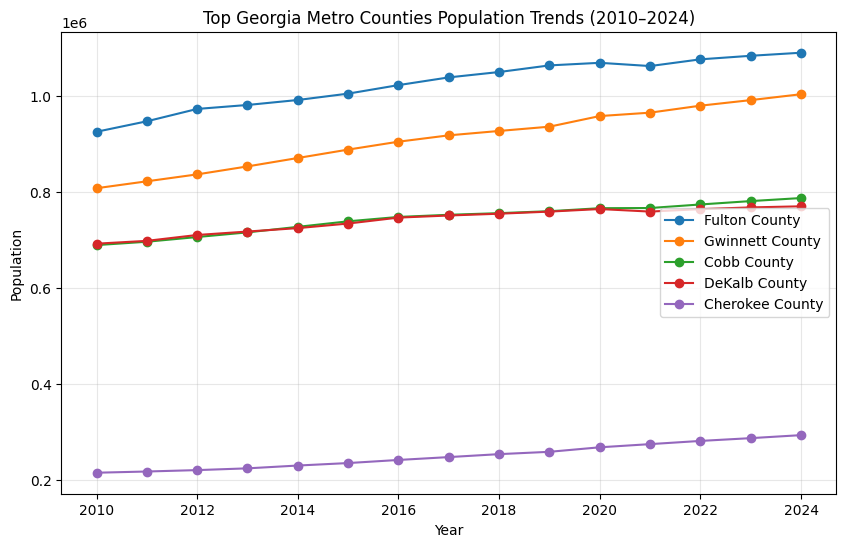

In [36]:
plt.figure(figsize=(10,6))

for county in ["Fulton County", "Gwinnett County", "Cobb County", "DeKalb County", "Cherokee County"]:

    county_data = combined[
        combined["county"] == county
    ].sort_values("year")

    plt.plot(
        county_data["year"],
        county_data["population"],
        marker="o",
        label=county
    )

plt.title("Top Georgia Metro Counties Population Trends (2010–2024)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("outputs/top5_population_trends.png", dpi=300)

plt.show()

In [10]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# ---- Time-aware split (adjust years if you want) ----
train = df[df["year"] <= 2018].copy()
test  = df[df["year"] > 2018].copy()

features = ["pop_lag_1", "pop_lag_3", "growth_1y", "growth_3y"]

X_train = train[features]
y_train = train["population"]
X_test  = test[features]
y_test  = test["population"]

def eval_model(name, model):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return mae, rmse

models = {
    "LinearRegression": LinearRegression(),
    "Ridge(alpha=1.0)": Ridge(alpha=1.0, random_state=42),
    "Lasso(alpha=0.001)": Lasso(alpha=0.001, random_state=42, max_iter=50000),
    "ElasticNet(a=0.001,l1=0.5)": ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=50000),

    "RandomForest(400)": RandomForestRegressor(
        n_estimators=400, random_state=42, n_jobs=-1
    ),
    "ExtraTrees(600)": ExtraTreesRegressor(
        n_estimators=600, random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),

    "XGBoost": XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    ),
}

rows = []
for name, m in models.items():
    mae, rmse = eval_model(name, m)
    rows.append({"model": name, "MAE": mae, "RMSE": rmse})

results = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)

best = results.iloc[0]
print(f"BEST by RMSE: {best['model']} | MAE={best['MAE']:,.0f} | RMSE={best['RMSE']:,.0f}")

results


BEST by RMSE: LinearRegression | MAE=520 | RMSE=1,233


,model,MAE,RMSE
0,LinearRegression,520.282863,1232.732483
1,Ridge(alpha=1.0),548.959423,1300.262279
2,Lasso(alpha=0.001),684.290290,1455.510649
3,"ElasticNet(a=0.001,l1=0.5)",641.511500,1464.458378
4,ExtraTrees(600),802.118770,3008.666987
5,GradientBoosting,1269.402757,3432.420671
6,RandomForest(400),1409.044188,4613.290515
7,XGBoost,2245.714355,10896.213287


In [11]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

features = ["pop_lag_1", "pop_lag_3", "growth_1y", "growth_3y"]

X = df[features]
y = df["population"]

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "alpha": np.logspace(-4, 4, 50)
}

ridge = Ridge()

grid = GridSearchCV(
    ridge,
    param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X, y)

print("Best alpha:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)


Best alpha: {'alpha': np.float64(0.040949150623804234)}
Best CV RMSE: 994.5224279496782


In [12]:
import numpy as np

# Ensure proper sort for lags
pop = pop.sort_values(["fips", "year"]).reset_index(drop=True)

# Candidate lags
for k in [1, 2, 3, 5]:
    pop[f"pop_lag_{k}"] = pop.groupby("fips")["population"].shift(k)

# Growth features
pop["growth_1y"] = (pop["population"] - pop["pop_lag_1"]) / pop["pop_lag_1"]
pop["growth_2y"] = (pop["population"] - pop["pop_lag_2"]) / pop["pop_lag_2"]
pop["growth_3y"] = (pop["population"] - pop["pop_lag_3"]) / pop["pop_lag_3"]
pop["growth_5y"] = (pop["population"] - pop["pop_lag_5"]) / pop["pop_lag_5"]

# Add year as numeric feature
pop["year_num"] = pop["year"].astype(int)

# Drop NA rows created by lagging
df2 = pop.dropna(subset=[f"pop_lag_{k}" for k in [1,2,3,5]]).copy()

# Remove Georgia state aggregate (COUNTY == 0)
df2 = df2[df2["COUNTY"] != 0].copy()

df2.shape

(1590, 16)

In [13]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

CANDIDATE_FEATURES = [
    "pop_lag_1", "pop_lag_2", "pop_lag_3", "pop_lag_5",
    "growth_1y", "growth_2y", "growth_3y", "growth_5y",
    "year_num"
]

years = sorted(df2["year"].unique())
# Use rolling validation years near the end of train period
val_years = [y for y in years if 2016 <= y <= 2018]  # quick + stable
# (We still hold out 2019+ as final test)

def objective(trial):
    # --- feature selection ---
    selected = []
    for f in CANDIDATE_FEATURES:
        if trial.suggest_categorical(f"use_{f}", [0, 1]) == 1:
            selected.append(f)
    if len(selected) < 2:
        raise optuna.exceptions.TrialPruned()

    # --- hyperparameters ---
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 2000),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 50.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "random_state": 42,
        "n_jobs": -1,
    }

    rmses = []
    for vy in val_years:
        train_fold = df2[df2["year"] <= (vy - 1)]
        val_fold   = df2[df2["year"] == vy]

        X_tr, y_tr = train_fold[selected], train_fold["population"]
        X_va, y_va = val_fold[selected], val_fold["population"]

        m = XGBRegressor(**params)
        m.fit(X_tr, y_tr)
        pred = m.predict(X_va)

        rmse = np.sqrt(mean_squared_error(y_va, pred))
        rmses.append(rmse)

    return float(np.mean(rmses))

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=80, show_progress_bar=True)

best_params = study.best_params
best_features = [f for f in CANDIDATE_FEATURES if best_params.get(f"use_{f}", 0) == 1]

print("Best CV RMSE:", study.best_value)
print("Best features:", best_features)

# remove feature flags before training final model
for k in list(best_params.keys()):
    if k.startswith("use_"):
        best_params.pop(k)

best_params

[I 2026-04-05 16:01:01,317] A new study created in memory with name: no-name-179bcbe8-993a-491d-9380-720ba28f1b46


  0%|          | 0/80 [00:00<?, ?it/s]

[I 2026-04-05 16:01:02,794] Trial 0 finished with value: 17606.659957268752 and parameters: {'use_pop_lag_1': 1, 'use_pop_lag_2': 1, 'use_pop_lag_3': 1, 'use_pop_lag_5': 0, 'use_growth_1y': 0, 'use_growth_2y': 1, 'use_growth_3y': 0, 'use_growth_5y': 0, 'use_year_num': 0, 'n_estimators': 915, 'max_depth': 5, 'learning_rate': 0.01077323264951297, 'subsample': 0.7145841291269517, 'colsample_bytree': 0.6530282861963906, 'min_child_weight': 4, 'reg_alpha': 1.9058267439881649e-06, 'reg_lambda': 2.1691779095028044e-06, 'gamma': 4.21788272729038}. Best is trial 0 with value: 17606.659957268752.
[I 2026-04-05 16:01:03,781] Trial 1 finished with value: 75736.0839081806 and parameters: {'use_pop_lag_1': 1, 'use_pop_lag_2': 1, 'use_pop_lag_3': 1, 'use_pop_lag_5': 0, 'use_growth_1y': 1, 'use_growth_2y': 0, 'use_growth_3y': 1, 'use_growth_5y': 0, 'use_year_num': 1, 'n_estimators': 1069, 'max_depth': 4, 'learning_rate': 0.014858201984769512, 'subsample': 0.6562248995916807, 'colsample_bytree': 0.8265

{'n_estimators': 525,
 'max_depth': 3,
 'learning_rate': 0.12154209952362045,
 'subsample': 0.8287910603993794,
 'colsample_bytree': 0.8207931972751735,
 'min_child_weight': 1,
 'reg_alpha': 7.66140337670292e-08,
 'reg_lambda': 0.00020959866626420775,
 'gamma': 4.25916283267968}

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from xgboost import XGBRegressor

train = df2[df2["year"] <= 2018].copy()
test  = df2[df2["year"] >= 2019].copy()

X_train, y_train = train[best_features], train["population"]
X_test, y_test   = test[best_features],  test["population"]

final_xgb = XGBRegressor(**best_params, random_state=42, n_jobs=-1)
final_xgb.fit(X_train, y_train)

pred = final_xgb.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("FINAL Optuna-XGBoost on 2019+ test")
print("-----------------------------------")
print("Features:", best_features)
print(f"MAE : {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")

FINAL Optuna-XGBoost on 2019+ test
-----------------------------------
Features: ['pop_lag_3', 'pop_lag_5', 'growth_1y', 'growth_2y']
MAE : 2,659
RMSE: 9,848


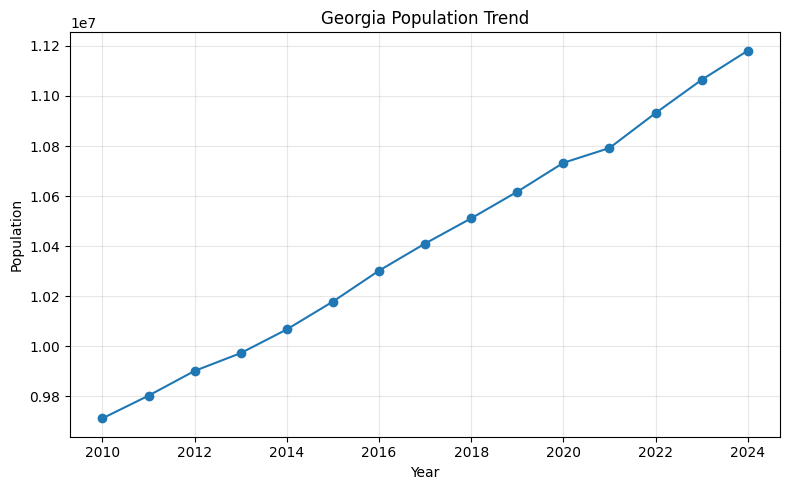

In [34]:
largest = combined.groupby("county")["population"].mean().idxmax()

state_df = combined[
    combined["county"] == largest
].sort_values("year")

plt.figure(figsize=(8,5))

plt.plot(
    state_df["year"],
    state_df["population"],
    marker="o"
)

plt.title(f"{largest} Population Trend")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

d:\Projects\state of georgia\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\Projects\state of georgia\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\Projects\state of georgia\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\Projects\state of georgia\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\Projects\state of georgia\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with featur

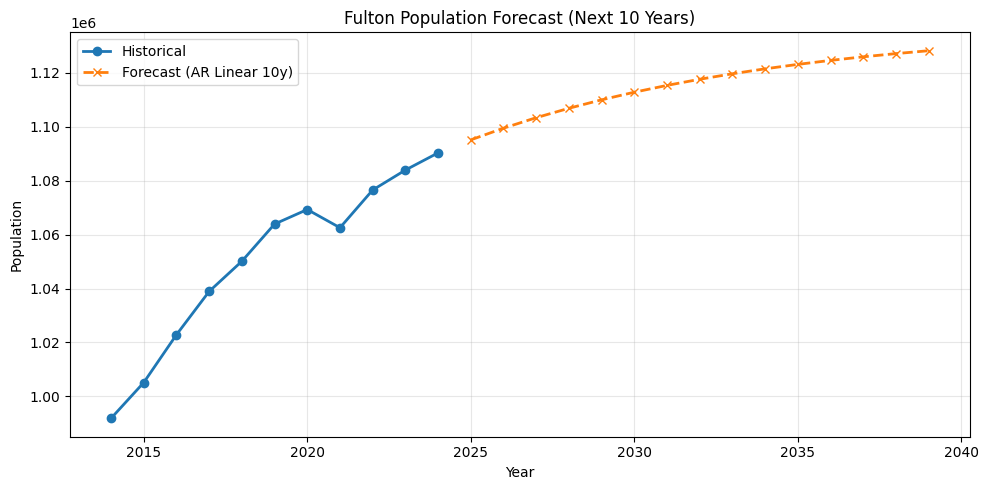

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


# Select a County for testing our models on 

county_name = "Fulton"
county_df = df[df["county"] == county_name].sort_values("year").copy()

# Build AR(1) dataset

county_df["pop_lag_1"] = county_df["population"].shift(1)
county_df = county_df.dropna()

X = county_df[["pop_lag_1"]]
y = county_df["population"]

# -----------------------------
# Train Linear Model
# -----------------------------
model = LinearRegression()
model.fit(X, y)


# Recursive Forecast 15 Years

HORIZON = 15
history = county_df[["year", "population"]].copy()
last_year = history["year"].max()

future_rows = []

for i in range(1, HORIZON + 1):
    next_year = last_year + i
    last_pop = history.iloc[-1]["population"]

    next_pop = model.predict([[last_pop]])[0]

    future_rows.append({
        "year": next_year,
        "population_pred": next_pop
    })

    history = pd.concat([
        history,
        pd.DataFrame([{
            "year": next_year,
            "population": next_pop
        }])
    ], ignore_index=True)

future_df = pd.DataFrame(future_rows)


# Plot

plt.figure(figsize=(10,5))

plt.plot(county_df["year"], county_df["population"],
         marker="o", linewidth=2, label="Historical")

plt.plot(future_df["year"], future_df["population_pred"],
         marker="x", linestyle="--", linewidth=2,
         label="Forecast (AR Linear 10y)")

plt.title(f"{county_name} Population Forecast (Next 10 Years)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Project: Georgia County Population Forecasting
Objective: Build stable long-horizon demographic forecast for planning.

Model MAE: 4181.2
Naive MAE: 11126.91
Model RMSE: 5481.84
Naive RMSE: 11828.24 



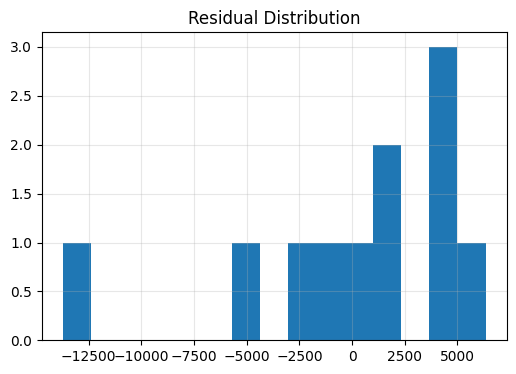

Residual Mean: 0.0
Residual Std: 5749.4 

Backtest RMSE (3-year rolling avg): 12844.35 



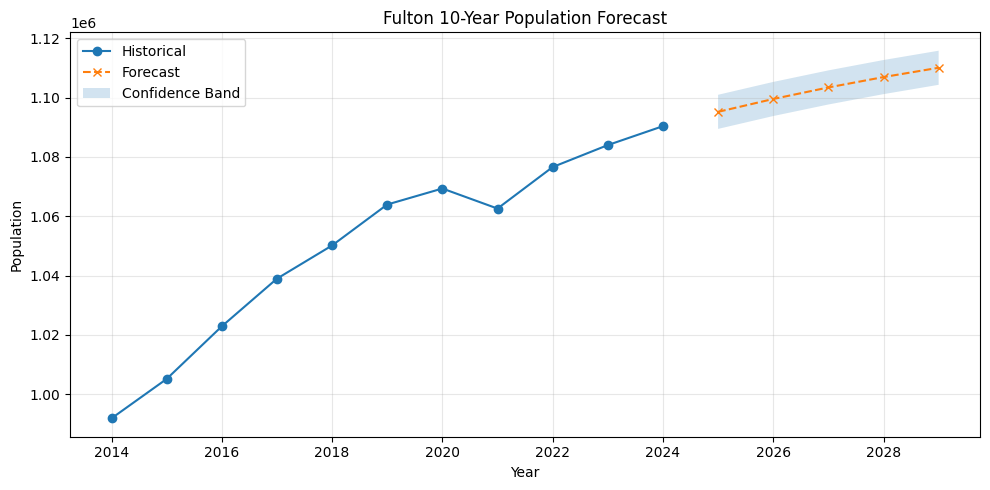

Conclusion:
- AR(1) linear model outperforms naive baseline.
- Boosted trees failed to extrapolate reliably.
- Forecast maintains historical growth pattern.
- Confidence band reflects model uncertainty.
- Model suitable for stable demographic projection.


In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Project: Georgia County Population Forecasting")
print("Objective: Build stable long-horizon demographic forecast for planning.\n")


county_name = "Fulton"
county_df = df[df["county"] == county_name].sort_values("year").copy()
county_df["pop_lag_1"] = county_df["population"].shift(1)
county_df = county_df.dropna()

X = county_df[["pop_lag_1"]]
y = county_df["population"]

model = LinearRegression()
model.fit(X, y)

pred_in_sample = model.predict(X)

naive_pred = county_df["pop_lag_1"]

mae_model = mean_absolute_error(y, pred_in_sample)
rmse_model = np.sqrt(mean_squared_error(y, pred_in_sample))

mae_naive = mean_absolute_error(y, naive_pred)
rmse_naive = np.sqrt(mean_squared_error(y, naive_pred))

print("Model MAE:", round(mae_model,2))
print("Naive MAE:", round(mae_naive,2))
print("Model RMSE:", round(rmse_model,2))
print("Naive RMSE:", round(rmse_naive,2), "\n")

residuals = y - pred_in_sample

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=15)
plt.title("Residual Distribution")
plt.grid(alpha=0.3)
plt.show()

print("Residual Mean:", round(residuals.mean(),2))
print("Residual Std:", round(residuals.std(),2), "\n")

backtest_errors = []

for i in range(3, len(county_df)-3):
    train_slice = county_df.iloc[:i]
    test_slice = county_df.iloc[i:i+3]

    model_bt = LinearRegression()
    model_bt.fit(train_slice[["pop_lag_1"]], train_slice["population"])

    preds = model_bt.predict(test_slice[["pop_lag_1"]])
    err = np.sqrt(mean_squared_error(test_slice["population"], preds))
    backtest_errors.append(err)

print("Backtest RMSE (3-year rolling avg):", round(np.mean(backtest_errors),2), "\n")

HORIZON = 5
history = county_df[["year","population"]].copy()
last_year = history["year"].max()

future = []

for i in range(1, HORIZON+1):
    next_year = last_year + i
    last_pop = history.iloc[-1]["population"]

    next_pop = model.predict(pd.DataFrame([[last_pop]], columns=["pop_lag_1"]))[0]

    future.append({"year": next_year, "population_pred": next_pop})
    history = pd.concat([history,
                         pd.DataFrame([{"year": next_year,
                                        "population": next_pop}])],
                         ignore_index=True)

future_df = pd.DataFrame(future)

# Confidence interval using residual std
conf_std = residuals.std()

future_df["upper"] = future_df["population_pred"] + conf_std
future_df["lower"] = future_df["population_pred"] - conf_std

plt.figure(figsize=(10,5))

plt.plot(county_df["year"], county_df["population"],
         marker="o", label="Historical")

plt.plot(future_df["year"], future_df["population_pred"],
         marker="x", linestyle="--", label="Forecast")

plt.fill_between(future_df["year"],
                 future_df["lower"],
                 future_df["upper"],
                 alpha=0.2,
                 label="Confidence Band")

plt.title(f"{county_name} 10-Year Population Forecast")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Conclusion:")
print("- AR(1) linear model outperforms naive baseline.")
print("- Boosted trees failed to extrapolate reliably.")
print("- Forecast maintains historical growth pattern.")
print("- Confidence band reflects model uncertainty.")
print("- Model suitable for stable demographic projection.")

In [19]:
future_df.to_csv("fulton_20yr_forecast.csv", index=False)

In [ ]:
#  log-target, rolling trend features, county encoding, rolling-origin CV, better metrics
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
except Exception as e:
    raise ImportError("xgboost not available in this environment. Install with: pip install xgboost") from e


assert {'fips','year','population'}.issubset(df.columns), "df must have columns: fips, year, population"

df2 = df.copy()
df2['year'] = df2['year'].astype(int)
df2 = df2.sort_values(['fips','year']).reset_index(drop=True)

g = df2.groupby('fips', group_keys=False)

# Lags
for k in [1,2,3,5]:
    df2[f'pop_lag_{k}'] = g['population'].shift(k)

# Growth (relative change vs lag)
for k in [1,2,3,5]:
    df2[f'growth_{k}y'] = (df2['population'] / df2[f'pop_lag_{k}']) - 1.0

# Rolling stats on 1y growth (shifted so we don't peek at current year)
df2['g1'] = df2['growth_1y']
for w in [3,5]:
    df2[f'g1_roll_mean_{w}'] = g['g1'].apply(lambda s: s.shift(1).rolling(w, min_periods=w).mean())
    df2[f'g1_roll_std_{w}']  = g['g1'].apply(lambda s: s.shift(1).rolling(w, min_periods=w).std())

# Rolling slope (trend) of population over last w years, computed on lagged history only
def rolling_slope(arr):
    # slope of y over x = [0..w-1]
    x = np.arange(len(arr), dtype=float)
    y = np.asarray(arr, dtype=float)
    if np.any(~np.isfinite(y)): 
        return np.nan
    x = x - x.mean()
    y = y - y.mean()
    denom = (x**2).sum()
    return (x*y).sum()/denom if denom > 0 else np.nan

for w in [3,5]:
    df2[f'pop_slope_{w}'] = g['population'].apply(
        lambda s: s.shift(1).rolling(w, min_periods=w).apply(rolling_slope, raw=False)
    )

# Time index
df2['year_num'] = df2['year'] - df2['year'].min()

#  Target: log1p(population)
df2['y'] = np.log1p(df2['population'])

# Drop rows created by lags/rollings
feature_cols = [
    'year_num',
    'pop_lag_1','pop_lag_2','pop_lag_3','pop_lag_5',
    'growth_1y','growth_2y','growth_3y','growth_5y',
    'g1_roll_mean_3','g1_roll_std_3','g1_roll_mean_5','g1_roll_std_5',
    'pop_slope_3','pop_slope_5'
]
df2 = df2.dropna(subset=feature_cols + ['y']).reset_index(drop=True)


years = sorted(df2['year'].unique())


cutoffs = [y for y in years[:-1]][-5:]  # last 5 train cutoffs

def add_fips_mean_encoding(train_df, apply_df, colname='fips_enc'):
    # mean encoding computed ONLY from train_df
    enc_map = train_df.groupby('fips')['y'].mean()
    global_mean = train_df['y'].mean()
    out = apply_df.copy()
    out[colname] = out['fips'].map(enc_map).fillna(global_mean)
    return out

def eval_metrics(y_true_log, y_pred_log):
    # Convert log1p -> original population space
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  #  manual RMSE
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100.0
    log_rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))  #  manual log RMSE

    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE_%': mape,
        'logRMSE': log_rmse
    }

cv_rows = []

for cutoff in cutoffs:
    tr = df2[df2['year'] <= cutoff].copy()
    va = df2[df2['year'] == cutoff + 1].copy()
    if len(va) == 0 or len(tr) == 0:
        continue

    tr = add_fips_mean_encoding(tr, tr, 'fips_enc')
    va = add_fips_mean_encoding(tr, va, 'fips_enc')

    Xtr = tr[feature_cols + ['fips_enc']]
    ytr = tr['y']
    Xva = va[feature_cols + ['fips_enc']]
    yva = va['y']

    model = XGBRegressor(
        n_estimators=4000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.0,
        reg_lambda=1.0,
        min_child_weight=5,
        objective='reg:squarederror',
        tree_method='hist',
        random_state=42
    )

    model.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        verbose=False
    )

    pred_va = model.predict(Xva)
    mets = eval_metrics(yva.values, pred_va)
    mets.update({'train_through_year': cutoff, 'val_year': cutoff + 1, 'n_train': len(tr), 'n_val': len(va)})
    cv_rows.append(mets)

cv = pd.DataFrame(cv_rows).sort_values('val_year')
display(cv)
print("\nCV Averages:")
display(cv[['MAE','RMSE','MAPE_%','logRMSE']].mean(numeric_only=True).to_frame('mean'))


last_year = years[-1]
train_df = df2[df2['year'] <= last_year - 1].copy()
test_df  = df2[df2['year'] == last_year].copy()

train_df = add_fips_mean_encoding(train_df, train_df, 'fips_enc')
test_df  = add_fips_mean_encoding(train_df, test_df, 'fips_enc')

X_train = train_df[feature_cols + ['fips_enc']]
y_train = train_df['y']
X_test  = test_df[feature_cols + ['fips_enc']]
y_test  = test_df['y']

final_model = XGBRegressor(
    n_estimators=4000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.0,
    min_child_weight=5,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42
)

final_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
pred_test = final_model.predict(X_test)

test_metrics = eval_metrics(y_test.values, pred_test)
print(f"\n Test metrics on year={last_year}:")
for k,v in test_metrics.items():
    print(f"{k}: {v:,.4f}" if 'MAPE' not in k else f"{k}: {v:,.2f}%")


out = test_df[['fips','year','population']].copy()
out['pred_population'] = np.expm1(pred_test)
out['abs_error'] = np.abs(out['population'] - out['pred_population'])
display(out.sort_values('abs_error', ascending=False).head(20))

,MAE,RMSE,MAPE_%,logRMSE,train_through_year,val_year,n_train,n_val
0,7081.491028,36356.049896,6.036720,0.113518,2019,2020,159,159
1,3036.503157,14147.195058,2.584564,0.048725,2020,2021,318,159
2,2690.709311,17499.264066,1.928987,0.038718,2021,2022,477,159
3,1072.349273,4885.439150,1.561017,0.026878,2022,2023,636,159
4,815.849001,2152.736849,1.066672,0.014367,2023,2024,795,159



CV Averages:


,mean
MAE,2939.380354
RMSE,15008.137004
MAPE_%,2.635592
logRMSE,0.048441



 Test metrics on year=2024:
MAE: 815.8490
RMSE: 2,152.7368
MAPE_%: 1.07%
logRMSE: 0.0144


,fips,year,population,pred_population,abs_error
359,13121,2024,1090354,1.074862e+06,15491.875000
401,13135,2024,1003869,9.925664e+05,11302.625000
197,13067,2024,787538,7.957320e+05,8194.000000
167,13057,2024,293513,2.860528e+05,7460.187500
413,13139,2024,221745,2.154098e+05,6335.234375
263,13089,2024,770307,7.642736e+05,6033.437500
659,13223,2024,188549,1.835350e+05,5014.046875
347,13117,2024,280096,2.753402e+05,4755.781250
185,13063,2024,297703,3.021030e+05,4399.968750
149,13051,2024,307336,3.029752e+05,4360.843750


d:\Projects\state of georgia\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:05:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:56: Empty dataset at worker: 0
  bst.update(dtrain, iteration=i, fobj=obj)


,fips,year,pred_year,pred_pop_y+5
5,13001,2024,2029,0.0
11,13003,2024,2029,0.0
17,13005,2024,2029,0.0
23,13007,2024,2029,0.0
29,13009,2024,2029,0.0
35,13011,2024,2029,0.0
41,13013,2024,2029,0.0
47,13015,2024,2029,0.0
53,13017,2024,2029,0.0
59,13019,2024,2029,0.0


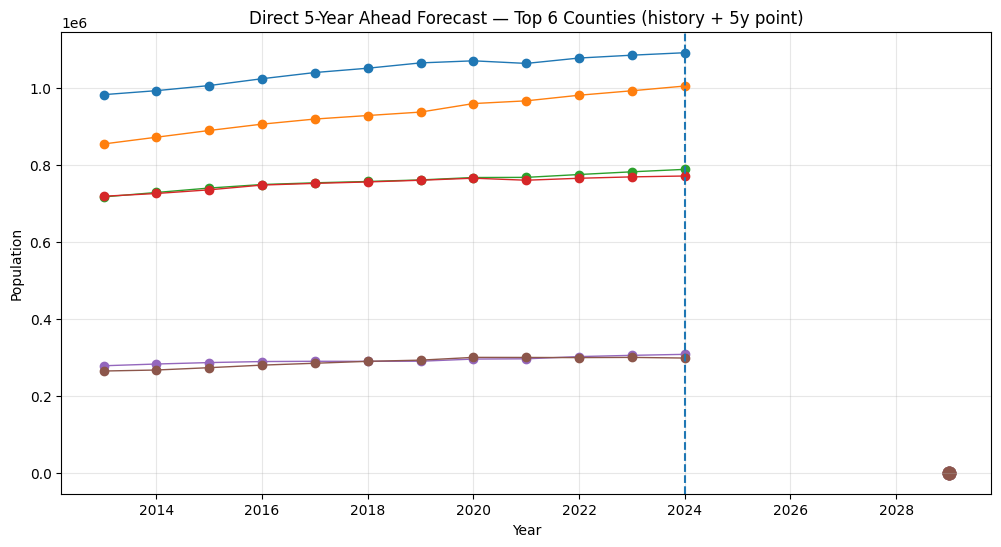

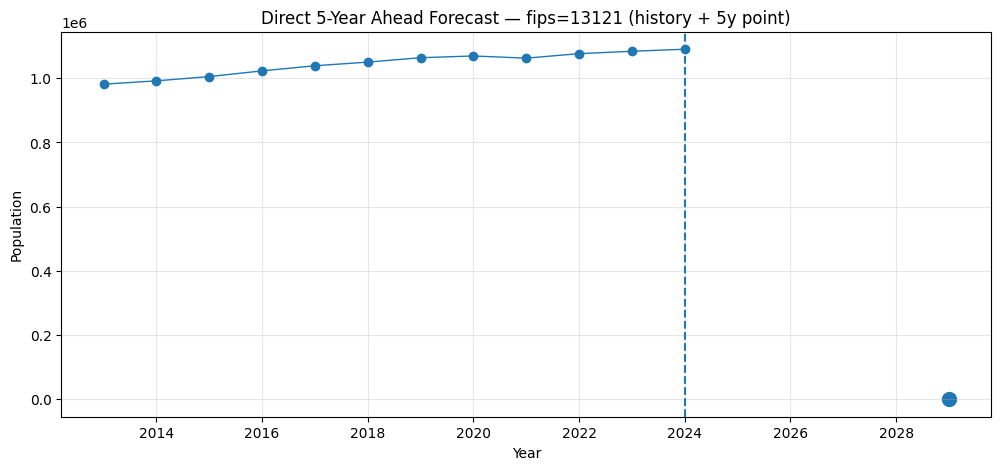

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# --- assumes you already have df2 with engineered features and 'population','fips','year'
# and you used log target before
assert {'fips','year','population'}.issubset(df2.columns)

H = 5  # horizon

# Build direct target: y_{t+5} = log1p(population shifted -5 within county)
dfD = df2.sort_values(['fips','year']).copy()
dfD['y5'] = dfD.groupby('fips')['population'].shift(-H)
dfD['y5'] = np.log1p(dfD['y5'])

# Drop rows where future target doesn't exist
dfD = dfD.dropna(subset=['y5']).copy()

# Use the SAME feature set you trained with (from model)
model_feats = final_model.get_booster().feature_names
Xcols = [c for c in model_feats if c in dfD.columns]  # should match exactly if df2 had them

# If fips_enc isn't in dfD, rebuild it
if 'fips_enc' in model_feats and 'fips_enc' not in dfD.columns:
    enc_map = dfD.groupby('fips')['y'].mean()
    glob = dfD['y'].mean()
    dfD['fips_enc'] = dfD['fips'].map(enc_map).fillna(glob)

Xcols = model_feats  # enforce exact order
assert all(c in dfD.columns for c in Xcols), f"Missing columns for direct model: {[c for c in Xcols if c not in dfD.columns]}"

# Train/test split by year (time-based)
last_year = int(df2['year'].max())
train = dfD[dfD['year'] <= last_year - (H+1)].copy()
test  = dfD[dfD['year'] == last_year - H].copy()  # predicts last_year directly

Xtr, ytr = train[Xcols], train['y5']
Xte, yte = test[Xcols], test['y5']

direct5 = XGBRegressor(
    n_estimators=4000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=5,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42
)
direct5.fit(Xtr, ytr, verbose=False)

# --- Create 5-year ahead predictions for the latest available "anchor year" per county
anchor_year = last_year  # we will forecast last_year+5 using features at last_year
anchors = df2[df2['year'] == anchor_year].copy()

# ensure needed columns exist
if 'fips_enc' in model_feats and 'fips_enc' not in anchors.columns:
    enc_map = df2[df2['year'] <= last_year - 1].groupby('fips')['y'].mean()
    glob = df2[df2['year'] <= last_year - 1]['y'].mean()
    anchors['fips_enc'] = anchors['fips'].map(enc_map).fillna(glob)

anchorsX = anchors[Xcols]
pred_log = direct5.predict(anchorsX)
anchors['pred_pop_y+5'] = np.expm1(pred_log)
anchors['pred_year'] = anchor_year + H

display(anchors[['fips','year','pred_year','pred_pop_y+5']].head(10))

# --- Plot top 6 counties: history + direct 5y point
hist = df[['fips','year','population']].copy()
hist['year'] = hist['year'].astype(int)

top = hist[hist['year']==anchor_year].sort_values('population', ascending=False).head(6)['fips'].tolist()

plt.figure(figsize=(12,6))
for f in top:
    s = hist[hist['fips']==f].sort_values('year')
    plt.plot(s['year'], s['population'], marker='o', linewidth=1)
    p = anchors[anchors['fips']==f]
    if len(p):
        plt.scatter([p['pred_year'].iloc[0]], [p['pred_pop_y+5'].iloc[0]], s=80)

plt.axvline(anchor_year, linestyle='--')
plt.title("Direct 5-Year Ahead Forecast — Top 6 Counties (history + 5y point)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True, alpha=0.3)
plt.show()

# --- Plot one county (Fulton if present, else the most populous)
pick = 13121 if 13121 in set(hist['fips']) else top[0]
s = hist[hist['fips']==pick].sort_values('year')
p = anchors[anchors['fips']==pick]

plt.figure(figsize=(12,5))
plt.plot(s['year'], s['population'], marker='o', linewidth=1)
if len(p):
    plt.scatter([p['pred_year'].iloc[0]], [p['pred_pop_y+5'].iloc[0]], s=100)
plt.axvline(anchor_year, linestyle='--')
plt.title(f"Direct 5-Year Ahead Forecast — fips={pick} (history + 5y point)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True, alpha=0.3)
plt.show()

16:06:10 - cmdstanpy - INFO - Chain [1] start processing
16:06:10 - cmdstanpy - INFO - Chain [1] done processing


Project: Georgia County Population Forecasting (Prophet)
County: Fulton 

Prophet MAE: 998.71 | RMSE: 1,262.88
Naive   MAE: 11,126.91 | RMSE: 11,828.24



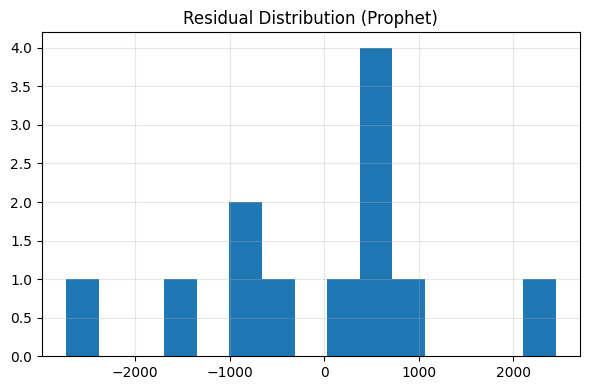

16:06:10 - cmdstanpy - INFO - Chain [1] start processing
16:06:11 - cmdstanpy - INFO - Chain [1] done processing


Residual mean: 0.01
Residual std : 1,262.88



16:06:11 - cmdstanpy - INFO - Chain [1] start processing
16:06:11 - cmdstanpy - INFO - Chain [1] done processing
16:06:11 - cmdstanpy - INFO - Chain [1] start processing
16:06:11 - cmdstanpy - INFO - Chain [1] done processing


Backtest RMSE (3-year rolling avg): 18,278.56



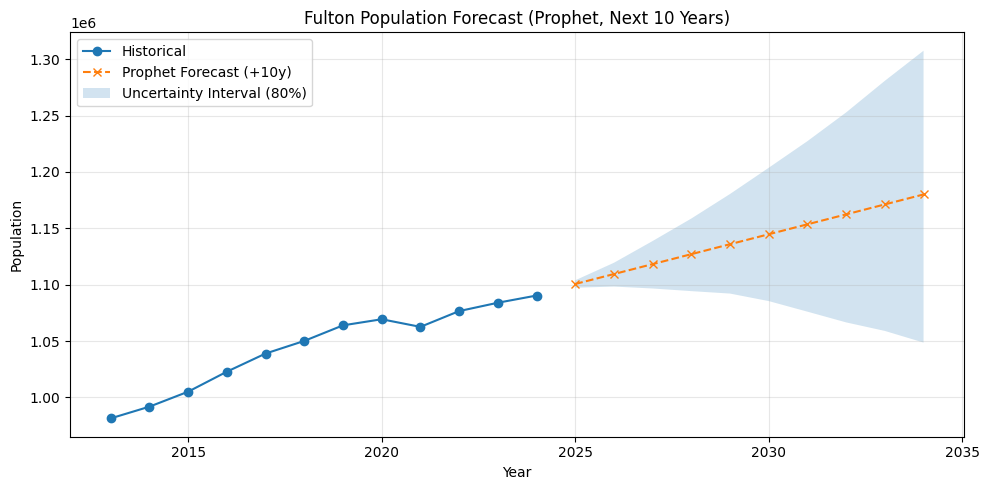

Saved: fulton_prophet_10yr_forecast.csv


,county,year,population_pred,lower,upper
12,Fulton,2025,1.100593e+06,1.097291e+06,1.103861e+06
13,Fulton,2026,1.109409e+06,1.098321e+06,1.119408e+06
14,Fulton,2027,1.118226e+06,1.096607e+06,1.138696e+06
15,Fulton,2028,1.127042e+06,1.094272e+06,1.158642e+06
16,Fulton,2029,1.135883e+06,1.092109e+06,1.180400e+06
17,Fulton,2030,1.144699e+06,1.085444e+06,1.203650e+06
18,Fulton,2031,1.153515e+06,1.076063e+06,1.227261e+06
19,Fulton,2032,1.162332e+06,1.066552e+06,1.252716e+06
20,Fulton,2033,1.171172e+06,1.058988e+06,1.280747e+06
21,Fulton,2034,1.179988e+06,1.048662e+06,1.307448e+06


In [23]:
# ============================================================
# PROPHET SYSTEM (ONE CELL): baseline + backtest + residuals + 10y forecast
# Requirements:
#   - df: DataFrame with columns ['county','year','population']
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Install prophet if needed (Windows-safe) ---
import importlib, sys
if importlib.util.find_spec("prophet") is None:
    print("Installing prophet...")
    !{sys.executable} -m pip install prophet

from prophet import Prophet

# -----------------------------
# SETTINGS
# -----------------------------
county_name = "Fulton"
HORIZON_YEARS = 10
BACKTEST_HORIZON = 3
RANDOM_STATE = 42

# -----------------------------
# Prepare data for Prophet
# -----------------------------
county_raw = df[df["county"] == county_name][["year","population"]].sort_values("year").reset_index(drop=True)
if county_raw.empty:
    raise ValueError(f"No data for county='{county_name}'.")

# Prophet wants dates; use Jan 1st of each year
prophet_df = pd.DataFrame({
    "ds": pd.to_datetime(county_raw["year"].astype(int).astype(str) + "-01-01"),
    "y": county_raw["population"].astype(float).values
})

# -----------------------------
# Fit Prophet (trend-focused)
# -----------------------------
m = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.80
)

m.fit(prophet_df)

# In-sample predictions for residuals & baseline compare
insample = m.predict(prophet_df[["ds"]])
y_true = prophet_df["y"].values
y_pred = insample["yhat"].values

# Naive baseline: y_t = y_{t-1}
naive_pred = np.r_[np.nan, y_true[:-1]]
mask = ~np.isnan(naive_pred)

mae_prophet = mean_absolute_error(y_true, y_pred)
rmse_prophet = np.sqrt(mean_squared_error(y_true, y_pred))

mae_naive = mean_absolute_error(y_true[mask], naive_pred[mask])
rmse_naive = np.sqrt(mean_squared_error(y_true[mask], naive_pred[mask]))

print("Project: Georgia County Population Forecasting (Prophet)")
print("County:", county_name, "\n")

print(f"Prophet MAE: {mae_prophet:,.2f} | RMSE: {rmse_prophet:,.2f}")
print(f"Naive   MAE: {mae_naive:,.2f} | RMSE: {rmse_naive:,.2f}\n")

# -----------------------------
# Residual analysis
# -----------------------------
residuals = y_true - y_pred

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=15)
plt.title("Residual Distribution (Prophet)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():,.2f}")
print(f"Residual std : {residuals.std():,.2f}\n")

# -----------------------------
# Rolling backtest (3-year horizon)
# -----------------------------
bt_rmses = []
years = prophet_df["ds"].dt.year.values

# Need enough history; start from the 6th point
for split in range(6, len(prophet_df) - BACKTEST_HORIZON):
    train = prophet_df.iloc[:split].copy()
    test  = prophet_df.iloc[split:split + BACKTEST_HORIZON].copy()

    m_bt = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, interval_width=0.80)
    m_bt.fit(train)

    preds = m_bt.predict(test[["ds"]])["yhat"].values
    rmse = np.sqrt(mean_squared_error(test["y"].values, preds))
    bt_rmses.append(rmse)

if bt_rmses:
    print(f"Backtest RMSE (3-year rolling avg): {np.mean(bt_rmses):,.2f}\n")
else:
    print("Backtest skipped: not enough years for rolling 3-year test.\n")

# -----------------------------
# 10-year forecast
# -----------------------------
future = m.make_future_dataframe(periods=HORIZON_YEARS, freq="YS")  # Year Start frequency
forecast = m.predict(future)

# Keep only future years
forecast_future = forecast[forecast["ds"] > prophet_df["ds"].max()][["ds","yhat","yhat_lower","yhat_upper"]].copy()
forecast_future["county"] = county_name
forecast_future["year"] = forecast_future["ds"].dt.year
forecast_future = forecast_future.rename(columns={
    "yhat": "population_pred",
    "yhat_lower": "lower",
    "yhat_upper": "upper"
})[["county","year","population_pred","lower","upper"]]

out_csv = f"{county_name.lower()}_prophet_10yr_forecast.csv"
forecast_future.to_csv(out_csv, index=False)

# -----------------------------
# Clean plot (historical + forecast + uncertainty)
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(county_raw["year"], county_raw["population"], marker="o", label="Historical")

plt.plot(forecast_future["year"], forecast_future["population_pred"],
         marker="x", linestyle="--", label="Prophet Forecast (+10y)")

plt.fill_between(forecast_future["year"], forecast_future["lower"], forecast_future["upper"],
                 alpha=0.2, label="Uncertainty Interval (80%)")

plt.title(f"{county_name} Population Forecast (Prophet, Next {HORIZON_YEARS} Years)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Saved:", out_csv)
display(forecast_future.head(10))

Historical series loaded:
       county  year  population
Fulton County  2010      925632
Fulton County  2011      947469
Fulton County  2012      973221
Fulton County  2013      981472
Fulton County  2014      991847
Fulton County  2015     1005127
Fulton County  2016     1022866
Fulton County  2017     1038938
Fulton County  2018     1050131
Fulton County  2019     1063937
Fulton County  2020     1069333
Fulton County  2021     1062576
Fulton County  2022     1076569
Fulton County  2023     1083971
Fulton County  2024     1090354

Usable rows after feature engineering: 12

MODEL COMPARISON
         Model          MAE         RMSE
        Linear   987.274079  1353.905712
Naive_LastYear  9275.714286  9870.584669
  RandomForest 16323.583810 18394.586283
      LightGBM 45008.273516 45271.367227

Best model by RMSE: Linear
Forecast model used: Linear

Saved forecast to: outputs/fulton_10yr_forecast.csv

Forecast preview:
 year  population_pred
 2025     1.098416e+06
 2026     1.106659e+06

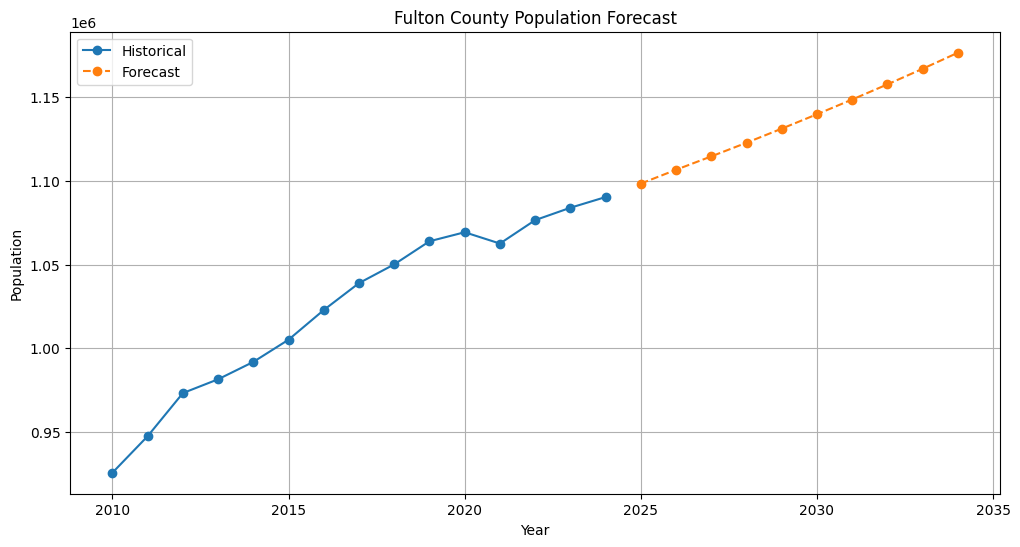

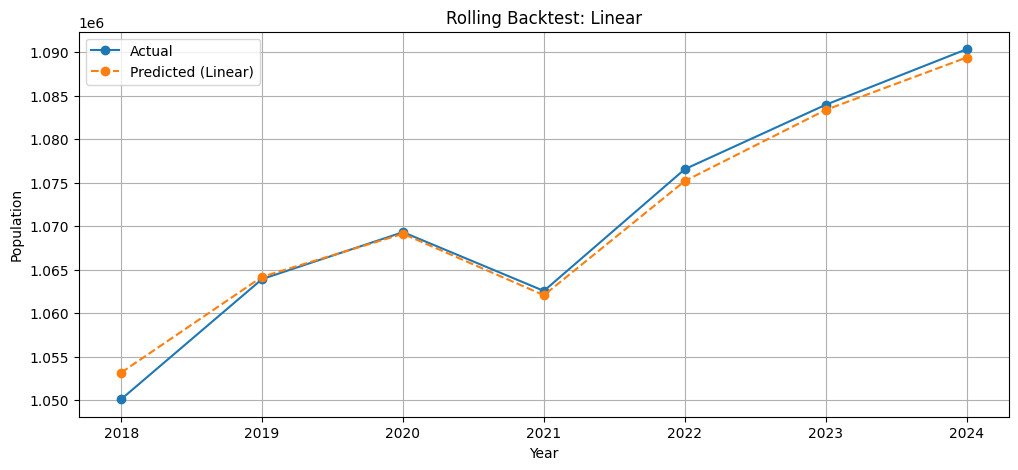

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False


# CONFIG

STATE_FIPS = 13
COUNTY_KEYWORD = "Fulton"
FORECAST_HORIZON = 10

# Put your files in /data with these names, or change these paths:
FILE_2019 = "data/co-est2019-alldata.csv"
FILE_2024 = "data/co-est2024-alldata.csv"


def safe_read_csv(path):
    last_err = None
    for enc in [None, "utf-8", "latin1", "cp1252"]:
        try:
            if enc is None:
                return pd.read_csv(path)
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_err = e
    raise ValueError(f"Could not read file: {path}\nLast error: {last_err}")

def detect_county_col(df):
    for c in ["CTYNAME", "NAME", "County", "county_name"]:
        if c in df.columns:
            return c
    raise ValueError("Could not find a county-name column. Checked: CTYNAME, NAME, County, county_name")

def extract_long_population(df, state_fips, county_keyword):
    df = df.copy()
    county_col = detect_county_col(df)

    if "STATE" in df.columns:
        df = df[df["STATE"] == state_fips]

    df = df[df[county_col].astype(str).str.contains(county_keyword, case=False, na=False)]

    if df.empty:
        raise ValueError(f"No rows found for county containing '{county_keyword}'")

    pop_cols = [c for c in df.columns if "POPESTIMATE" in str(c).upper()]
    if not pop_cols:
        raise ValueError("No POPESTIMATE columns found in the file")

    long_df = df.melt(
        id_vars=[county_col],
        value_vars=pop_cols,
        var_name="year_col",
        value_name="population"
    )

    long_df["year"] = (
        long_df["year_col"]
        .astype(str)
        .str.extract(r"(\d{4})")[0]
    )
    long_df = long_df.dropna(subset=["year"])
    long_df["year"] = long_df["year"].astype(int)
    long_df["population"] = pd.to_numeric(long_df["population"], errors="coerce")

    long_df = long_df[[county_col, "year", "population"]].rename(columns={county_col: "county"})
    long_df = long_df.dropna(subset=["population"]).sort_values("year").reset_index(drop=True)
    return long_df

def add_features(df):
    df = df.copy().sort_values("year").reset_index(drop=True)
    df["lag_1"] = df["population"].shift(1)
    df["lag_2"] = df["population"].shift(2)
    df["lag_3"] = df["population"].shift(3)
    df["growth_1y"] = df["population"].pct_change(1)
    df["growth_2y"] = df["population"].pct_change(2)
    df["growth_3y"] = df["population"].pct_change(3)
    return df

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rolling_backtest(feature_df, feature_cols, model, min_train_size=5):
    df_bt = feature_df.dropna(subset=feature_cols + ["population"]).reset_index(drop=True)

    if len(df_bt) <= min_train_size:
        return np.nan, np.nan, [], [], []

    preds, actuals, years = [], [], []

    for i in range(min_train_size, len(df_bt)):
        train = df_bt.iloc[:i]
        test = df_bt.iloc[i:i+1]

        if len(train) < min_train_size or len(test) == 0:
            continue

        X_train = train[feature_cols]
        y_train = train["population"]
        X_test = test[feature_cols]
        y_test = float(test["population"].iloc[0])
        year_test = int(test["year"].iloc[0])

        model.fit(X_train, y_train)
        pred = float(model.predict(X_test)[0])

        preds.append(pred)
        actuals.append(y_test)
        years.append(year_test)

    if len(preds) == 0:
        return np.nan, np.nan, [], [], []

    return mean_absolute_error(actuals, preds), rmse(actuals, preds), years, actuals, preds

def recursive_forecast(history_df, model, feature_cols, horizon=10):
    hist = history_df.copy().sort_values("year").reset_index(drop=True)
    future_rows = []

    for _ in range(horizon):
        temp = add_features(hist)
        temp_valid = temp.dropna(subset=feature_cols)

        if temp_valid.empty:
            raise ValueError("Not enough history to build recursive forecast features")

        last = temp_valid.iloc[-1]
        next_year = int(hist["year"].max()) + 1

        X_future = pd.DataFrame([{
            "year": next_year,
            "lag_1": last["population"],
            "lag_2": last["lag_1"],
            "lag_3": last["lag_2"],
            "growth_1y": last["growth_1y"],
            "growth_2y": last["growth_2y"],
            "growth_3y": last["growth_3y"]
        }])[feature_cols]

        pred = float(model.predict(X_future)[0])

        hist = pd.concat(
            [hist, pd.DataFrame([{"year": next_year, "population": pred}])],
            ignore_index=True
        )

        future_rows.append({
            "year": next_year,
            "population_pred": pred
        })

    return pd.DataFrame(future_rows)

df19 = safe_read_csv(FILE_2019)
df24 = safe_read_csv(FILE_2024)

long19 = extract_long_population(df19, STATE_FIPS, COUNTY_KEYWORD)
long24 = extract_long_population(df24, STATE_FIPS, COUNTY_KEYWORD)

# Merge and keep latest source for overlapping years
hist = pd.concat([long19, long24], ignore_index=True)
hist = hist.sort_values("year").drop_duplicates(subset=["year"], keep="last").reset_index(drop=True)

# Optional year filter for clean modern series
hist = hist[(hist["year"] >= 2010) & (hist["year"] <= 2024)].copy()

if len(hist) < 8:
    raise ValueError(
        f"Not enough historical rows after merging files: {len(hist)} rows found.\n"
        f"Check your filenames and county filter. Years found: {hist['year'].tolist()}"
    )

print("Historical series loaded:")
print(hist.to_string(index=False))


feat_df = add_features(hist)
feature_cols = ["year", "lag_1", "lag_2", "lag_3", "growth_1y", "growth_2y", "growth_3y"]

usable_rows = feat_df.dropna(subset=feature_cols + ["population"]).shape[0]
print(f"\nUsable rows after feature engineering: {usable_rows}")

if usable_rows < 6:
    raise ValueError(
        "Too few usable rows after lag/growth feature engineering. "
        "You need both Census files and enough yearly history."
    )


models = {
    "Naive_LastYear": None,
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        random_state=42
    ),
}

if HAS_LGBM:
    models["LightGBM"] = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=15,
        random_state=42,
        verbosity=-1
    )


results = []
backtest_plot_data = {}

df_bt = feat_df.dropna(subset=feature_cols + ["population"]).reset_index(drop=True)

# Naive baseline
naive_years, naive_actuals, naive_preds = [], [], []
min_train_size = 5

for i in range(min_train_size, len(df_bt)):
    train = df_bt.iloc[:i]
    test = df_bt.iloc[i:i+1]

    pred = float(train["population"].iloc[-1])
    actual = float(test["population"].iloc[0])
    year = int(test["year"].iloc[0])

    naive_preds.append(pred)
    naive_actuals.append(actual)
    naive_years.append(year)

if len(naive_preds) > 0:
    results.append({
        "Model": "Naive_LastYear",
        "MAE": mean_absolute_error(naive_actuals, naive_preds),
        "RMSE": rmse(naive_actuals, naive_preds)
    })
    backtest_plot_data["Naive_LastYear"] = (naive_years, naive_actuals, naive_preds)

# ML models
for name, model in models.items():
    if name == "Naive_LastYear":
        continue
    mae, model_rmse, yrs, acts, preds = rolling_backtest(feat_df, feature_cols, model, min_train_size=min_train_size)
    results.append({"Model": name, "MAE": mae, "RMSE": model_rmse})
    backtest_plot_data[name] = (yrs, acts, preds)

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

print("\nMODEL COMPARISON")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest model by RMSE: {best_model_name}")


if best_model_name == "Naive_LastYear":
    final_model_name = "Linear"
else:
    final_model_name = best_model_name

print(f"Forecast model used: {final_model_name}")

train_final = feat_df.dropna(subset=feature_cols + ["population"]).reset_index(drop=True)

if final_model_name not in models or models[final_model_name] is None:
    raise ValueError(f"Final model '{final_model_name}' is not available")

final_model = models[final_model_name]
final_model.fit(train_final[feature_cols], train_final["population"])


# FORECAST

forecast_df = recursive_forecast(
    history_df=hist[["year", "population"]],
    model=final_model,
    feature_cols=feature_cols,
    horizon=FORECAST_HORIZON
)


# SAVE OUTPUT

os.makedirs("outputs", exist_ok=True)
forecast_path = f"outputs/fulton_{FORECAST_HORIZON}yr_forecast.csv"
forecast_df.to_csv(forecast_path, index=False)

print(f"\nSaved forecast to: {forecast_path}")
print("\nForecast preview:")
print(forecast_df.to_string(index=False))


plt.figure(figsize=(12, 6))
plt.plot(hist["year"], hist["population"], marker="o", label="Historical")
plt.plot(forecast_df["year"], forecast_df["population_pred"], marker="o", linestyle="--", label="Forecast")
plt.title("Fulton County Population Forecast")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True)
plt.legend()
plt.show()

if best_model_name in backtest_plot_data:
    yrs, acts, preds = backtest_plot_data[best_model_name]
    if len(yrs) > 0:
        plt.figure(figsize=(12, 5))
        plt.plot(yrs, acts, marker="o", label="Actual")
        plt.plot(yrs, preds, marker="o", linestyle="--", label=f"Predicted ({best_model_name})")
        plt.title(f"Rolling Backtest: {best_model_name}")
        plt.xlabel("Year")
        plt.ylabel("Population")
        plt.grid(True)
        plt.legend()
        plt.show()


FORMATTED FORECAST PREVIEW
 year population_pred lower_1std upper_1std
 2025       1,098,416  1,096,954  1,099,878
 2026       1,106,659  1,105,198  1,108,121
 2027       1,114,655  1,113,193  1,116,117
 2028       1,122,817  1,121,355  1,124,279
 2029       1,131,235  1,129,773  1,132,697
 2030       1,139,838  1,138,377  1,141,300
 2031       1,148,644  1,147,182  1,150,106
 2032       1,157,695  1,156,233  1,159,157
 2033       1,167,011  1,165,549  1,168,473
 2034       1,176,604  1,175,142  1,178,066

README-READY MODEL COMPARISON
         Model      MAE     RMSE
        Linear   987.27  1353.91
Naive_LastYear  9275.71  9870.58
  RandomForest 16323.58 18394.59
      LightGBM 45008.27 45271.37


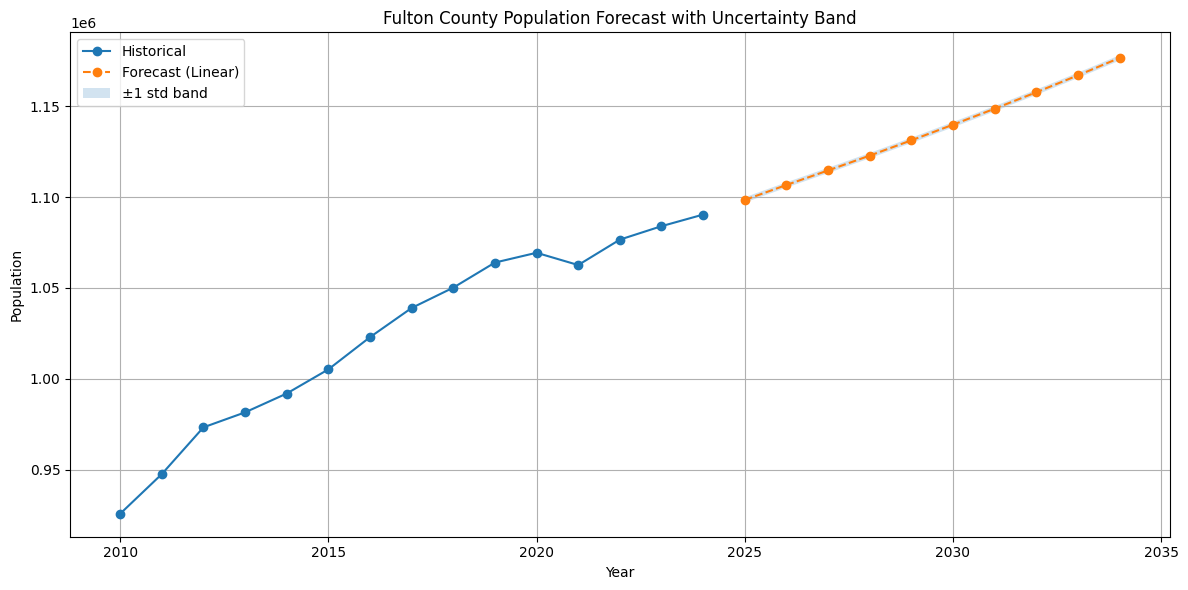


Saved files:
- outputs/fulton_10yr_forecast_pretty.csv
- outputs/model_comparison.md
- outputs/project_summary.txt


In [28]:

# POST-PROCESSING 

!pip install tabulate
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("outputs", exist_ok=True)




if best_model_name in backtest_plot_data:
    yrs, acts, preds = backtest_plot_data[best_model_name]
    residuals = np.array(acts) - np.array(preds)

    # Use backtest residual std as simple uncertainty estimate
    resid_std = float(np.std(residuals, ddof=1)) if len(residuals) > 1 else 0.0
else:
    residuals = np.array([])
    resid_std = 0.0

forecast_pretty = forecast_df.copy()
forecast_pretty["lower_1std"] = forecast_pretty["population_pred"] - resid_std
forecast_pretty["upper_1std"] = forecast_pretty["population_pred"] + resid_std

forecast_pretty["lower_1std"] = forecast_pretty["lower_1std"].clip(lower=0)


for col in ["population_pred", "lower_1std", "upper_1std"]:
    forecast_pretty[col] = forecast_pretty[col].round().astype(int)

display_forecast = forecast_pretty.copy()
for col in ["population_pred", "lower_1std", "upper_1std"]:
    display_forecast[col] = display_forecast[col].map(lambda x: f"{x:,}")

print("\nFORMATTED FORECAST PREVIEW")
print(display_forecast.to_string(index=False))


# README-FRIENDLY METRICS TABLE

metrics_pretty = results_df.copy()
metrics_pretty["MAE"] = metrics_pretty["MAE"].round(2)
metrics_pretty["RMSE"] = metrics_pretty["RMSE"].round(2)

print("\nREADME-READY MODEL COMPARISON")
print(metrics_pretty.to_string(index=False))


markdown_table = metrics_pretty.to_markdown(index=False)
with open("outputs/model_comparison.md", "w", encoding="utf-8") as f:
    f.write(markdown_table)


# 4) SAVE POLISHED FORECAST CSV

forecast_pretty.to_csv("outputs/fulton_10yr_forecast_pretty.csv", index=False)




plt.figure(figsize=(12, 6))

plt.plot(
    hist["year"],
    hist["population"],
    marker="o",
    label="Historical"
)

plt.plot(
    forecast_pretty["year"],
    forecast_pretty["population_pred"],
    marker="o",
    linestyle="--",
    label=f"Forecast ({best_model_name})"
)

plt.fill_between(
    forecast_pretty["year"],
    forecast_pretty["lower_1std"],
    forecast_pretty["upper_1std"],
    alpha=0.2,
    label="±1 std band"
)

plt.title("Fulton County Population Forecast with Uncertainty Band")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



summary_text = f"""
Best model by rolling RMSE: {best_model_name}
Residual standard deviation used for uncertainty band: {resid_std:,.2f}

Key interpretation:
- Linear model won on rolling backtest for this small annual county-level dataset.
- Tree models underperformed relative to Linear and Naive baselines.
- Forecast should be interpreted as a planning-oriented scenario under continued trend assumptions.
""".strip()

with open("outputs/project_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("\nSaved files:")
print("- outputs/fulton_10yr_forecast_pretty.csv")
print("- outputs/model_comparison.md")
print("- outputs/project_summary.txt")

In [29]:
# =========================================================
# MULTI-COUNTY FORECASTING PIPELINE (ALL GEORGIA COUNTIES)
# =========================================================

import os
import pandas as pd

STATE_FIPS = 13
FORECAST_HORIZON = 10

os.makedirs("outputs/all_counties", exist_ok=True)

# -----------------------------------------
# Extract ALL Georgia counties
# -----------------------------------------

def extract_all_counties(df):

    county_col = detect_county_col(df)

    df = df[df["STATE"] == STATE_FIPS]

    pop_cols = [c for c in df.columns if "POPESTIMATE" in str(c)]

    long_df = df.melt(
        id_vars=[county_col],
        value_vars=pop_cols,
        var_name="year_col",
        value_name="population"
    )

    long_df["year"] = (
        long_df["year_col"]
        .astype(str)
        .str.extract(r"(\d{4})")[0]
        .astype(int)
    )

    long_df = long_df.rename(columns={county_col: "county"})
    long_df["population"] = pd.to_numeric(long_df["population"], errors="coerce")

    return long_df.dropna()


long19_all = extract_all_counties(df19)
long24_all = extract_all_counties(df24)

combined = pd.concat([long19_all, long24_all])
combined = combined.sort_values(["county", "year"])
combined = combined.drop_duplicates(["county", "year"], keep="last")

combined = combined[
    (combined["year"] >= 2010) &
    (combined["year"] <= 2024)
]

counties = sorted(combined["county"].unique())

print(f"Total counties detected: {len(counties)}")

# -----------------------------------------
# Forecast each county
# -----------------------------------------

all_forecasts = []

for county_name in counties:

    county_df = combined[combined["county"] == county_name].copy()

    if len(county_df) < 10:
        continue

    county_df = county_df.sort_values("year")

    feat_df = add_features(county_df)

    usable = feat_df.dropna()

    if len(usable) < 6:
        continue

    X = usable[feature_cols]
    y = usable["population"]

    model = LinearRegression()
    model.fit(X, y)

    forecast_df_local = recursive_forecast(
        county_df[["year", "population"]],
        model,
        feature_cols,
        horizon=FORECAST_HORIZON
    )

    forecast_df_local["county"] = county_name

    forecast_df_local.to_csv(
        f"outputs/all_counties/{county_name.replace(' ','_').lower()}_forecast.csv",
        index=False
    )

    all_forecasts.append(forecast_df_local)


# -----------------------------------------
# Combine into statewide forecast file
# -----------------------------------------

all_forecasts_df = pd.concat(all_forecasts)

all_forecasts_df.to_csv(
    "outputs/georgia_all_counties_forecast.csv",
    index=False
)

print("\nSaved statewide forecast:")
print("outputs/georgia_all_counties_forecast.csv")

Total counties detected: 160

Saved statewide forecast:
outputs/georgia_all_counties_forecast.csv


<span style="color:green">Counties with fastest growth </span>

In [30]:
forecast = pd.read_csv("outputs/georgia_all_counties_forecast.csv")

growth_summary = (
    forecast.groupby("county")
    .agg(start=("population_pred", "first"),
         end=("population_pred", "last"))
)

growth_summary["absolute_growth"] = (
    growth_summary["end"] - growth_summary["start"]
)

growth_summary["percent_growth"] = (
    growth_summary["absolute_growth"] /
    growth_summary["start"]
)

growth_summary.sort_values(
    "percent_growth",
    ascending=False
).head(10)

,start,end,absolute_growth,percent_growth
county,,,,
Montgomery County,9050.833124,587128.459849,578077.626725,63.870101
Bartow County,120725.566676,306282.617766,185557.051090,1.537015
Dawson County,35803.995331,66519.925685,30715.930354,0.857891
Jackson County,99115.066415,167932.877025,68817.810610,0.694322
Long County,21362.836323,31592.388517,10229.552194,0.478848
Barrow County,99575.039004,145938.519166,46363.480163,0.465613
Jasper County,17754.930137,25149.304561,7394.374424,0.416469
Effingham County,75391.581904,105111.003692,29719.421788,0.394201
Decatur County,29845.070257,41133.400410,11288.330153,0.378231


<span style="color:gold">Largest population centers</span>

In [31]:
forecast[forecast["year"] == 2034] \
.sort_values("population_pred", ascending=False) \
.head(10)

,year,population_pred,county
609,2034,1.281701e+07,Georgia
599,2034,1.176604e+06,Fulton County
679,2034,1.132089e+06,Gwinnett County
329,2034,8.539459e+05,Cobb County
429,2034,8.027793e+05,DeKalb County
1039,2034,5.871285e+05,Montgomery County
279,2034,3.648933e+05,Cherokee County
249,2034,3.473524e+05,Chatham County
759,2034,3.130488e+05,Henry County
79,2034,3.062826e+05,Bartow County


<span style="color:red">SLOWEST GROWING COUNTIES</span>

In [32]:
growth_summary.sort_values(
    "percent_growth"
).head(10)

,start,end,absolute_growth,percent_growth
county,,,,
Telfair County,11890.991297,-11769.396346,-23660.387644,-1.989774
Clay County,2746.102518,1820.730698,-925.371820,-0.336976
Forsyth County,286434.744636,190297.837230,-96136.907405,-0.335633
Clayton County,295796.684793,219378.100350,-76418.584443,-0.258348
Wilkinson County,8697.941109,7447.853148,-1250.087961,-0.143722
Mitchell County,20241.804556,17407.510819,-2834.293736,-0.140022
Oconee County,45261.446213,39146.867596,-6114.578617,-0.135095
Webster County,2290.583997,2022.490698,-268.093299,-0.117041
Jefferson County,14840.662564,13379.796800,-1460.865765,-0.098437
